# Simple Linear Regression — Google Colab

**Goal:** Predict a continuous target from one numeric feature using Simple Linear Regression.

| Example | Feature (X) | Target (y) | Dataset |
|---------|-------------|------------|---------|
| **Example 1** | SAT | GPA | `../Datasets/Simple linear regression.csv` |
| **Example 2** | YearsExperience | Salary | `../Datasets/experience_salary.csv` |

| Phase | Topic | Cells |
|-------|-------|-------|
| Phase 0 | Setup | Setup & Imports |
| Phase 1 | Data Pre-processing | Load → Cleaning → Encoding → Split |
| Phase 2 | Algorithm | Train → Predict → Visualize → Evaluate |

> **Run:** Runtime → Run all (or Ctrl+F9)

## Phase 0 — Cell 0: Install Libraries

Google Colab usually includes most libraries. This cell ensures required packages are available.

**What this cell does:** Installs scikit-learn, pandas, matplotlib, numpy, and seaborn quietly.

In [11]:
# Install into the same Python as this notebook kernel (avoids pip/kernel mismatch)
import sys
!{sys.executable} -m pip install -q scikit-learn pandas matplotlib numpy


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python3.11 -m pip install --upgrade pip


## Phase 0 — Cell 1: Import Libraries

Import libraries for data handling, preprocessing, modeling, and evaluation.

**What this cell does:** Loads numpy, pandas, matplotlib, seaborn, and sklearn modules.

In [12]:
# --- Import libraries ---
import numpy as np              # Numerical operations and arrays
import pandas as pd             # Load and manipulate tabular data
import matplotlib.pyplot as plt # Create charts and plots

from sklearn.model_selection import train_test_split  # Split data into train/test
from sklearn.impute import SimpleImputer              # Fill missing values
from sklearn.preprocessing import LabelEncoder, OneHotEncoder  # Encode categories
from sklearn.compose import ColumnTransformer         # Apply transforms to columns
from sklearn.linear_model import LinearRegression     # Simple Linear Regression model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # Evaluation metrics

plt.rcParams['figure.figsize'] = (10, 6)  # Default plot size: width=10, height=6 inches
plt.style.use('seaborn-v0_8-whitegrid')   # Clean white background with grid lines
np.random.seed(42)                          # Fix random seed for reproducible splits

print('Libraries ready')                      # Confirm all imports loaded successfully

Libraries ready


---
# Phase 1: Data Pre-processing

Prepare the data before training the model — same template is reused for other algorithms.

## Phase 1 — Cell 1: Load and Explore Data

Load the CSV file and perform initial exploration (head, info, describe, shape).

**What this cell does:** Reads `../Datasets/Simple linear regression.csv` and displays basic statistics.

In [13]:
# Step 1) Load dataset
dataset = pd.read_csv('../Datasets/Simple linear regression.csv')  # Read CSV into a DataFrame

print('First 5 rows:')          # Print a label for the table below
display(dataset.head())         # Show the first 5 rows to inspect the data

print('\nDataset info:')       # Print a label for column types and null counts
dataset.info()                  # Show column names, data types, and non-null counts

print('\nStatistical summary:')  # Print a label for numeric statistics
display(dataset.describe())       # Show count, mean, std, min, max, quartiles

print(f'\nShape: {dataset.shape[0]} rows x {dataset.shape[1]} columns')  # Total rows and columns

First 5 rows:


,SAT,GPA
0,1714,2.40
1,1664,2.52
2,1760,2.54
3,1685,2.74
4,1693,2.83



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SAT     100 non-null    int64  
 1   GPA     100 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 1.7 KB

Statistical summary:


,SAT,GPA
count,100.000000,100.000000
mean,1850.760000,3.360500
std,101.566331,0.258845
min,1634.000000,2.400000
25%,1776.500000,3.270000
50%,1850.000000,3.410000
75%,1934.000000,3.520000
max,2050.000000,3.810000



Shape: 100 rows x 2 columns


## Phase 1 — Cell 2: Data Cleaning (Handling Missing Values)

Data cleaning includes checking missing values, removing duplicates, and using SimpleImputer when needed.

**What this cell does:** Checks for nulls, drops duplicate rows, and prepares an imputer template for other datasets.

In [14]:
# Step 2) Data cleaning

# 1) Check missing values
print('Missing values per column:')  # Print a label
print(dataset.isnull().sum())        # Count NaN values in each column

# 2) Remove duplicate rows
rows_before = len(dataset)                              # Store row count before cleaning
dataset = dataset.drop_duplicates().reset_index(drop=True)  # Remove duplicates and reset row index
rows_after = len(dataset)                               # Store row count after cleaning
print(f'\nDuplicates removed: {rows_before - rows_after}')  # Show how many duplicates were removed

# 3) SimpleImputer — reusable template for other datasets
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')  # Replace NaN with column mean
if dataset.isnull().sum().sum() > 0:               # If any missing values exist
    dataset.iloc[:, :] = imputer.fit_transform(dataset)  # Learn means and fill missing values
    print('Missing values imputed with mean')      # Confirm imputation was applied
else:
    print('No missing values — imputer not applied')  # Skip imputation when data is complete

print(f'\nRows after cleaning: {rows_after}')    # Final number of rows in the dataset

Missing values per column:
SAT    0
GPA    0
dtype: int64

Duplicates removed: 17
No missing values — imputer not applied

Rows after cleaning: 83


## Phase 1 — Cell 3: Categorical Data Encoding

ML algorithms require numeric input. Categorical columns are encoded with One-Hot or Label Encoding. For SAT/GPA, all columns are numeric, so encoding is skipped.

**What this cell does:** Detects categorical columns and applies OneHotEncoder if needed; otherwise skips.

In [15]:
# Step 3) Categorical encoding

cat_cols = dataset.select_dtypes(include=['object', 'category']).columns.tolist()  # Find text/category columns
num_cols = dataset.select_dtypes(exclude=['object', 'category']).columns.tolist()  # Find numeric columns

if cat_cols:  # Run encoding only when categorical columns exist
    print(f'Categorical columns found: {cat_cols}')  # List columns that need encoding
    preprocessor = ColumnTransformer(  # Build a pipeline for selected columns
        transformers=[('encoder', OneHotEncoder(handle_unknown='ignore'), cat_cols)],  # One-hot encode categories
        remainder='passthrough'  # Keep other columns unchanged
    )
    dataset = pd.DataFrame(  # Convert encoded output back to a DataFrame
        preprocessor.fit_transform(dataset),  # Learn categories and transform data
        columns=preprocessor.get_feature_names_out()  # Use new encoded column names
    )
    print('One-Hot Encoding applied')  # Confirm encoding completed
else:
    print('No categorical columns — encoding skipped.')  # Nothing to encode in SAT/GPA dataset
    print(f'Numeric columns: {num_cols}')  # Show numeric columns used by the model

No categorical columns — encoding skipped.
Numeric columns: ['SAT', 'GPA']


## Phase 1 — Cell 4: Splitting the Data

Define feature X (SAT) and target y (GPA), then split into 80% training and 20% test sets.

**What this cell does:** Creates X, y arrays and applies train_test_split with random_state=42.

In [16]:
# Step 4) Train-Test split

# X = feature (SAT)
X = dataset[['SAT']].values  # Input feature matrix: SAT scores (2D array required by sklearn)

# y = target (GPA)
y = dataset['GPA'].values    # Output target vector: GPA values to predict

X_train, X_test, y_train, y_test = train_test_split(
    X, y,                  # Data to split
    test_size=0.2,         # 20% for testing, 80% for training
    random_state=42        # Fixed seed so split is reproducible every run
)

print(f'X_train shape: {X_train.shape}')  # Training features shape: (n_train, 1)
print(f'X_test shape:  {X_test.shape}')   # Test features shape: (n_test, 1)
print(f'y_train shape: {y_train.shape}')  # Training targets shape: (n_train,)
print(f'y_test shape:  {y_test.shape}')   # Test targets shape: (n_test,)

X_train shape: (66, 1)
X_test shape:  (17, 1)
y_train shape: (66,)
y_test shape:  (17,)


> **Note:** Simple Linear Regression does **not** require feature scaling with a single feature. Scaling is needed for SVR and KNN.

---
# Phase 2: Simple Linear Regression

Apply the simple linear regression algorithm: `GPA = b0 + b1 x SAT`

## Phase 2 — Cell 5: Train the Model

Train `LinearRegression` on the training data. The model learns the slope (b1) and intercept (b0).

**What this cell does:** Fits the regressor and prints intercept and slope coefficients.

In [17]:
# Step 5) Train model
regressor = LinearRegression()      # Create an empty Simple Linear Regression model
regressor.fit(X_train, y_train)     # Train the model: learn best b0 (intercept) and b1 (slope)

print(f'Intercept (b0): {regressor.intercept_:.4f}')   # Constant term where SAT = 0
print(f'Slope (b1):       {regressor.coef_[0]:.6f}')  # Change in GPA per 1-point increase in SAT
print(f'\nEquation: GPA = {regressor.intercept_:.4f} + {regressor.coef_[0]:.6f} x SAT')  # Final regression equation

Intercept (b0): 0.5410
Slope (b1):       0.001517

Equation: GPA = 0.5410 + 0.001517 x SAT


## Phase 2 — Cell 6: Predict

After training, the model predicts GPA values for the training and test sets.

**What this cell does:** Generates y_pred_train and y_pred_test using the fitted model.

In [29]:
# Step 6) Predict
y_pred_train = regressor.predict(X_train)  # Predict GPA for training SAT scores
y_pred_test = regressor.predict(X_test)    # Predict GPA for unseen test SAT scores

print('Sample predictions (Test set):')  # Print a label
for i in range(min(5, len(y_test))):     # Loop through first 5 test samples
    print(f'  SAT={X_test[i][0]:.0f} -> Actual GPA={y_test[i]:.2f}, Predicted={y_pred_test[i]:.2f}')  # Compare actual vs predicted

Sample predictions (Test set):
  SAT=3 -> Actual GPA=58797.00, Predicted=58093.35
  SAT=6 -> Actual GPA=72150.00, Predicted=80969.96
  SAT=8 -> Actual GPA=99596.00, Predicted=98356.18
  SAT=8 -> Actual GPA=101843.00, Predicted=103846.57
  SAT=7 -> Actual GPA=88363.00, Predicted=90120.60


## Phase 2 — Cell 7: Visualization

Scatter plot of the data with the regression line — training (blue), test (green), line (red).

**What this cell does:** Plots SAT vs GPA with the fitted regression line.

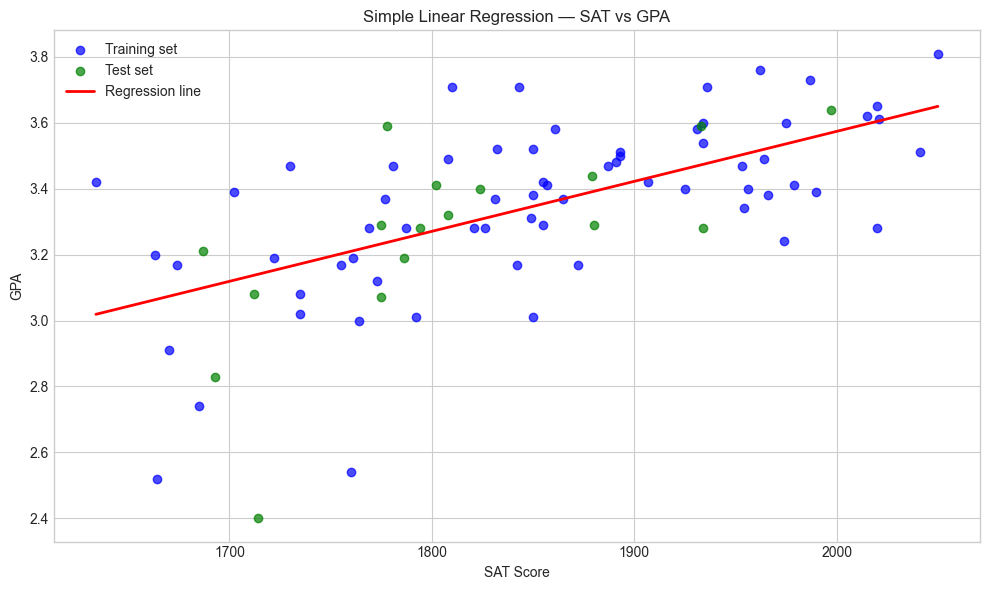

In [19]:
# Step 7) Visualization
plt.figure(figsize=(10, 6))  # Create a new figure with custom size
plt.scatter(X_train, y_train, color='blue', label='Training set', alpha=0.7)  # Plot training points
plt.scatter(X_test, y_test, color='green', label='Test set', alpha=0.7)       # Plot test points

# Regression line over full SAT range
X_line = np.linspace(dataset['SAT'].min(), dataset['SAT'].max(), 100).reshape(-1, 1)  # 100 SAT values from min to max
y_line = regressor.predict(X_line)  # Predict GPA for each SAT value on the line
plt.plot(X_line, y_line, color='red', linewidth=2, label='Regression line')  # Draw fitted regression line

plt.xlabel('SAT Score')  # Label for x-axis
plt.ylabel('GPA')       # Label for y-axis
plt.title('Simple Linear Regression — SAT vs GPA')  # Chart title
plt.legend()             # Show legend (Training, Test, Regression line)
plt.tight_layout()       # Adjust spacing so labels are not cut off
plt.show()               # Display the plot

## Phase 2 — Cell 8: Evaluation

Evaluate the model on the test set using MAE (Mean Absolute Error), RMSE (Root Mean Squared Error), and R² (Coefficient of Determination).

**What this cell does:** Computes and displays regression evaluation metrics.

In [20]:
# Step 8) Evaluation
mae = mean_absolute_error(y_test, y_pred_test)              # Average absolute prediction error
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))     # Square-root of average squared error
r2 = r2_score(y_test, y_pred_test)                          # Proportion of variance explained by the model

results = pd.DataFrame({  # Build a table of evaluation metrics
    'Metric': ['MAE', 'RMSE', 'R²'],  # Metric names
    'Value': [mae, rmse, r2],         # Computed metric values
    'Description': [                   # Short explanation of each metric
        'Mean Absolute Error',
        'Root Mean Squared Error',
        'Coefficient of Determination (1 = perfect)'
    ]
})

display(results.round(4))  # Show metrics rounded to 4 decimal places

,Metric,Value,Description
0,MAE,0.1551,Mean Absolute Error
1,RMSE,0.2297,Root Mean Squared Error
2,R²,0.3782,Coefficient of Determination (1 = perfect)


## Why is R² ≈ 0.3782?

**R² = 0.3782** means the model explains only about **38%** of the variation in GPA. Possible reasons:

| # | Reason | Explanation |
|---|--------|-------------|
| 1 | **Single feature (SAT only)** | GPA is affected by many factors (study habits, courses, attendance, school...) — SAT alone is not enough |
| 2 | **Relationship is not perfectly linear** | Simple Linear Regression assumes a straight line; the true relationship may be curved |
| 3 | **Data noise** | Students with the same SAT can have different GPAs — this lowers R² |
| 4 | **Duplicate rows removed** | After cleaning, only 83 rows remain — a smaller sample can affect stability |
| 5 | **Outliers** | Some students have high SAT but low GPA (or vice versa) — they pull points away from the line |
| 6 | **Simple model (Simple LR)** | A linear model with one feature may not capture all patterns — not necessarily underfitting, but **moderate fit** |

> **Summary:** R² = 0.3782 = **moderate fit** — the model learns a trend (SAT ↑ → GPA ↑) but does not predict with high accuracy.


---
# Example 2: Experience vs Salary — Ideal Simple Linear Regression Dataset

This dataset is designed for **Simple Linear Regression**:

| Column | Role | Description |
|--------|------|-------------|
| `YearsExperience` | Feature (X) | Years of work experience |
| `Salary` | Target (y) | Annual salary in USD |

**True relationship:** `Salary ≈ 25000 + 9500 × YearsExperience` (+ small noise)

**File:** `../Datasets/experience_salary.csv`

## Example 2 — Cell 1: Load and Explore Data

Load the Experience vs Salary CSV and inspect the data.

**What this cell does:** Reads `../Datasets/experience_salary.csv` and displays basic statistics.

In [21]:
# Load the SLR-friendly dataset
dataset = pd.read_csv('../Datasets/experience_salary.csv')  # Read CSV into a DataFrame

FEATURE_COL = 'YearsExperience'  # Independent variable (X)
TARGET_COL = 'Salary'              # Dependent variable (y)

print('First 5 rows:')          # Print a label for the table below
display(dataset.head())         # Show the first 5 rows to inspect the data

print('\nDataset info:')       # Print a label for column types and null counts
dataset.info()                  # Show column names, data types, and non-null counts

print('\nStatistical summary:')  # Print a label for numeric statistics
display(dataset.describe())       # Show count, mean, std, min, max, quartiles

print(f'\nShape: {dataset.shape[0]} rows x {dataset.shape[1]} columns')  # Total rows and columns

First 5 rows:


,YearsExperience,Salary
0,5.1,76404.0
1,11.5,134935.0
2,9.1,110987.0
3,7.6,95996.0
4,2.7,44736.0



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  49 non-null     float64
 1   Salary           49 non-null     float64
dtypes: float64(2)
memory usage: 932.0 bytes

Statistical summary:


,YearsExperience,Salary
count,49.000000,49.000000
mean,5.900000,81697.755102
std,3.217465,30147.484719
min,1.200000,36670.000000
25%,3.000000,57624.000000
50%,5.800000,81425.000000
75%,8.300000,101548.000000
max,11.700000,139559.000000



Shape: 50 rows x 2 columns


## Example 2 — Cell 2: Data Cleaning (Handling Missing Values)

This dataset includes a few missing values to demonstrate `SimpleImputer`.

**What this cell does:** Checks for nulls, removes duplicates, and imputes missing values.

In [22]:
# Data cleaning for Experience vs Salary

print('Missing values per column:')  # Print a label
print(dataset.isnull().sum())        # Count NaN values in each column

rows_before = len(dataset)                              # Store row count before cleaning
dataset = dataset.drop_duplicates().reset_index(drop=True)  # Remove duplicate rows
rows_after = len(dataset)                               # Store row count after deduplication
print(f'\nDuplicates removed: {rows_before - rows_after}')  # Show duplicate count

imputer = SimpleImputer(missing_values=np.nan, strategy='mean')  # Fill NaN with column mean
if dataset.isnull().sum().sum() > 0:               # If missing values exist
    dataset[[FEATURE_COL, TARGET_COL]] = imputer.fit_transform(dataset[[FEATURE_COL, TARGET_COL]])  # Impute numeric columns
    print('Missing values imputed with mean')      # Confirm imputation
else:
    print('No missing values — imputer not applied')  # Skip when complete

print(f'\nRows after cleaning: {rows_after}')    # Final row count

Missing values per column:
YearsExperience    1
Salary             1
dtype: int64

Duplicates removed: 0
Missing values imputed with mean

Rows after cleaning: 50


## Example 2 — Cell 3: Categorical Data Encoding

Both columns are numeric — encoding is skipped.

**What this cell does:** Detects categorical columns and applies encoding if needed.

In [23]:
# Categorical encoding

cat_cols = dataset.select_dtypes(include=['object', 'category']).columns.tolist()  # Find text/category columns
num_cols = dataset.select_dtypes(exclude=['object', 'category']).columns.tolist()  # Find numeric columns

if cat_cols:  # Encode only when categorical columns exist
    print(f'Categorical columns found: {cat_cols}')
    preprocessor = ColumnTransformer(
        transformers=[('encoder', OneHotEncoder(handle_unknown='ignore'), cat_cols)],
        remainder='passthrough'
    )
    dataset = pd.DataFrame(
        preprocessor.fit_transform(dataset),
        columns=preprocessor.get_feature_names_out()
    )
    print('One-Hot Encoding applied')
else:
    print('No categorical columns — encoding skipped.')
    print(f'Numeric columns: {num_cols}')

No categorical columns — encoding skipped.
Numeric columns: ['YearsExperience', 'Salary']


## Example 2 — Cell 4: Splitting the Data

Define X (`YearsExperience`) and y (`Salary`), then split 80/20.

**What this cell does:** Creates feature/target arrays and applies train_test_split.

In [24]:
# Train-Test split

X = dataset[[FEATURE_COL]].values  # Feature matrix: years of experience
y = dataset[TARGET_COL].values     # Target vector: salary values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,                  # Data to split
    test_size=0.2,         # 20% test, 80% train
    random_state=42        # Reproducible split
)

print(f'X_train shape: {X_train.shape}')  # Training features shape
print(f'X_test shape:  {X_test.shape}')   # Test features shape
print(f'y_train shape: {y_train.shape}')  # Training targets shape
print(f'y_test shape:  {y_test.shape}')   # Test targets shape

X_train shape: (40, 1)
X_test shape:  (10, 1)
y_train shape: (40,)
y_test shape:  (10,)


## Example 2 — Cell 5: Train the Model

Train Simple Linear Regression: `Salary = b0 + b1 × YearsExperience`

**What this cell does:** Fits the model and prints the regression equation.

In [25]:
# Train model
regressor = LinearRegression()      # Create Simple Linear Regression model
regressor.fit(X_train, y_train)     # Learn intercept (b0) and slope (b1)

print(f'Intercept (b0): {regressor.intercept_:.2f}')    # Base salary when experience = 0
print(f'Slope (b1):       {regressor.coef_[0]:.2f}')   # Salary increase per extra year
print(f'\nEquation: {TARGET_COL} = {regressor.intercept_:.2f} + {regressor.coef_[0]:.2f} x {FEATURE_COL}')

Intercept (b0): 27896.23
Slope (b1):       9150.64

Equation: Salary = 27896.23 + 9150.64 x YearsExperience


## Example 2 — Cell 6: Predict

Predict salary for training and test experience values.

**What this cell does:** Generates predictions and shows sample comparisons.

In [26]:
# Predict
y_pred_train = regressor.predict(X_train)  # Predict salary for training data
y_pred_test = regressor.predict(X_test)    # Predict salary for test data

print('Sample predictions (Test set):')
for i in range(min(5, len(y_test))):
    print(f'  {FEATURE_COL}={X_test[i][0]:.1f} -> Actual={y_test[i]:,.0f}, Predicted={y_pred_test[i]:,.0f}')

Sample predictions (Test set):
  YearsExperience=3.3 -> Actual=58,797, Predicted=58,093
  YearsExperience=5.8 -> Actual=72,150, Predicted=80,970
  YearsExperience=7.7 -> Actual=99,596, Predicted=98,356
  YearsExperience=8.3 -> Actual=101,843, Predicted=103,847
  YearsExperience=6.8 -> Actual=88,363, Predicted=90,121


## Example 2 — Cell 7: Visualization

Scatter plot with regression line for Experience vs Salary.

**What this cell does:** Plots data points and the fitted line.

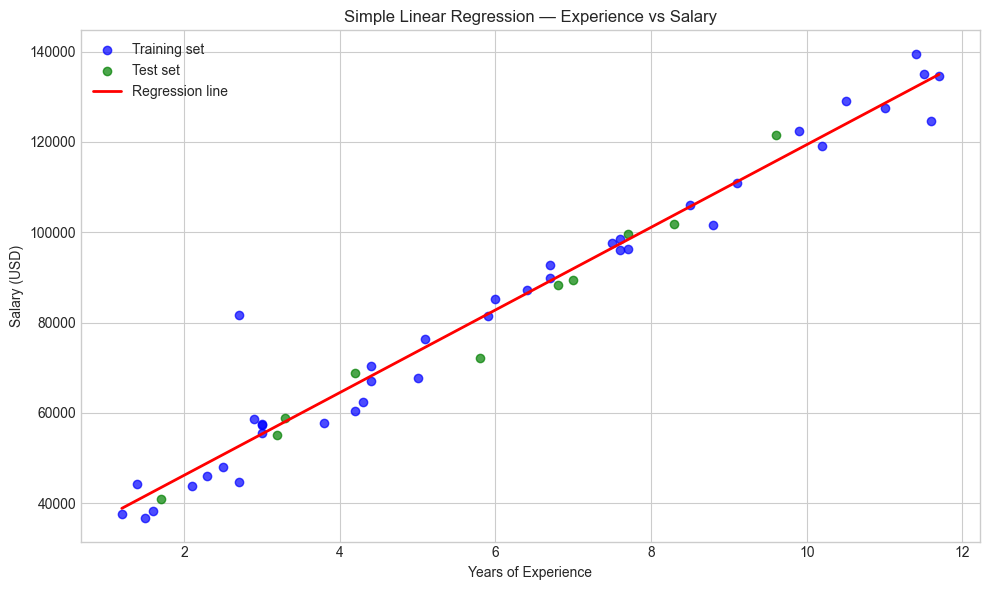

In [27]:
# Visualization
plt.figure(figsize=(10, 6))  # Create figure
plt.scatter(X_train, y_train, color='blue', label='Training set', alpha=0.7)  # Training points
plt.scatter(X_test, y_test, color='green', label='Test set', alpha=0.7)       # Test points

X_line = np.linspace(dataset[FEATURE_COL].min(), dataset[FEATURE_COL].max(), 100).reshape(-1, 1)  # Line x-values
y_line = regressor.predict(X_line)  # Line y-values from model
plt.plot(X_line, y_line, color='red', linewidth=2, label='Regression line')  # Draw regression line

plt.xlabel('Years of Experience')  # X-axis label
plt.ylabel('Salary (USD)')          # Y-axis label
plt.title('Simple Linear Regression — Experience vs Salary')  # Chart title
plt.legend()             # Show legend
plt.tight_layout()       # Adjust layout
plt.show()               # Display plot

## Example 2 — Cell 8: Evaluation

Evaluate model performance with MAE, RMSE, and R².

**What this cell does:** Computes and displays evaluation metrics on the test set.

In [28]:
# Evaluation
mae = mean_absolute_error(y_test, y_pred_test)              # Mean absolute error in USD
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))     # Root mean squared error
r2 = r2_score(y_test, y_pred_test)                          # Variance explained (closer to 1 is better)

results = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R²'],
    'Value': [mae, rmse, r2],
    'Description': [
        'Mean Absolute Error (USD)',
        'Root Mean Squared Error (USD)',
        'Coefficient of Determination (1 = perfect)'
    ]
})

display(results.round(4))

,Metric,Value,Description
0,MAE,2996.1598,Mean Absolute Error (USD)
1,RMSE,3801.3291,Root Mean Squared Error (USD)
2,R²,0.9739,Coefficient of Determination (1 = perfect)


## Why does this dataset work well for Simple Linear Regression?

| # | Reason | Explanation |
|---|--------|-------------|
| 1 | **Strong linear relationship** | Salary increases steadily with years of experience |
| 2 | **One feature, one target** | Matches the SLR requirement exactly |
| 3 | **Low noise** | Predictions stay close to the true line → **high R²** |
| 4 | **Clear interpretation** | Slope = extra salary per year of experience |
| 5 | **Missing values included** | Demonstrates data cleaning with `SimpleImputer` |

> **Compare:** SAT/GPA dataset had **R² ≈ 0.38** (moderate). This dataset typically achieves **R² > 0.90** (excellent fit).